In [49]:
# Find CSV files
import os

for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

./raw_data/data_cleaned.csv
./raw_data/data_featured.csv
./raw_data/startup data.csv
./raw_data/archive/big_startup_secsees_dataset.csv


In [50]:
# Current folder
import os
os.getcwd()

'/home/shakunt/code/Dr-Shakunt-Jadav/ssp'

In [51]:
# Imports
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [53]:
# Load cleaned data
df = pd.read_csv('./raw_data/data_cleaned.csv')

In [55]:
df_fe = pd.read_csv('./raw_data/data_cleaned.csv')

In [56]:
df_fe.shape

(66368, 9)

In [57]:
# Time taken to receive first funding
# May indicate how quickly investors saw potential in the startup
df_fe['years_to_first_funding'] = (
    df_fe['first_funding_year']
    - df_fe['founded_year']
)

In [58]:
# Length of funding activity
# Longer funding periods may reflect continued investor support
df_fe['funding_duration'] = (
    df_fe['last_funding_year']
    - df_fe['first_funding_year']
)

In [59]:
# Log transform funding amount
# Reduces the impact of extremely large funding values
df_fe['log_funding_total_usd'] = np.log1p(
    df_fe['funding_total_usd']
)

In [60]:
# Average funding raised per round
# Captures funding efficiency relative to fundraising activity
df_fe['funding_per_round'] = (
    df_fe['funding_total_usd']
    / df_fe['funding_rounds']
)

In [61]:
# Check new features
df_fe[
    [
        'years_to_first_funding',
        'funding_duration',
        'log_funding_total_usd',
        'funding_per_round'
    ]
].head()

,years_to_first_funding,funding_duration,log_funding_total_usd,funding_per_round
0,5.0,0.0,16.118096,10000000.0
1,0.0,0.0,13.458837,350000.0
2,4.0,0.0,15.041307,3406878.0
3,1.0,0.0,14.508658,2000000.0
4,4.0,0.0,14.508658,2000000.0


In [62]:
# Verify dataset size after feature creation
df_fe.shape

(66368, 13)

In [63]:
# Check missing values
df_fe.isnull().sum()

category_list                0
funding_total_usd            0
country_code              6958
state_code                8547
funding_rounds               0
target                       0
founded_year                 0
first_funding_year           0
last_funding_year            0
years_to_first_funding       0
funding_duration             0
log_funding_total_usd        0
funding_per_round            0
dtype: int64

In [65]:
# Startup received more than one funding round
df_fe['multiple_rounds'] = (
    df_fe['funding_rounds'] > 1
).astype(int)

In [66]:
# Startup received funding within 2 years
df_fe['early_funding'] = (
    df_fe['years_to_first_funding'] <= 2
).astype(int)

In [67]:
# Startup funding above median
median_funding = df_fe['funding_total_usd'].median()

df_fe['high_funding'] = (
    df_fe['funding_total_usd'] > median_funding
).astype(int)

In [68]:
# Check target balance
df_fe['target'].value_counts(normalize=True)

target
1    0.906009
0    0.093991
Name: proportion, dtype: float64

In [69]:
# Check correlations
df_fe.select_dtypes(include='number').corr()['target'].sort_values(
    ascending=False
)

target                    1.000000
last_funding_year         0.183009
first_funding_year        0.132620
multiple_rounds           0.086377
funding_rounds            0.078973
funding_duration          0.072640
years_to_first_funding    0.068458
log_funding_total_usd     0.048881
high_funding              0.040911
funding_total_usd         0.011998
funding_per_round         0.005854
founded_year             -0.013406
early_funding            -0.066202
Name: target, dtype: float64

In [70]:
# Show all columns
df_fe.columns.tolist()

['category_list',
 'funding_total_usd',
 'country_code',
 'state_code',
 'funding_rounds',
 'target',
 'founded_year',
 'first_funding_year',
 'last_funding_year',
 'years_to_first_funding',
 'funding_duration',
 'log_funding_total_usd',
 'funding_per_round',
 'multiple_rounds',
 'early_funding',
 'high_funding']

In [71]:
# View all engineered features
df_fe[
    [
        'years_to_first_funding',
        'funding_duration',
        'log_funding_total_usd',
        'funding_per_round',
        'multiple_rounds',
        'early_funding',
        'high_funding'
    ]
].head(10)

,years_to_first_funding,funding_duration,log_funding_total_usd,funding_per_round,multiple_rounds,early_funding,high_funding
0,5.0,0.0,16.118096,10000000.0,0,0,1
1,0.0,0.0,13.458837,350000.0,1,1,0
2,4.0,0.0,15.041307,3406878.0,0,0,1
3,1.0,0.0,14.508658,2000000.0,0,1,0
4,4.0,0.0,14.508658,2000000.0,0,0,0
5,4.0,0.0,10.627431,41250.0,0,0,0
6,12.0,0.0,13.544819,381425.5,1,0,0
7,2.0,2.0,17.330037,8400000.0,1,1,1
8,0.0,3.0,13.955317,383350.0,1,1,0
9,1.0,0.0,10.596660,40000.0,0,1,0


In [72]:
# Summary statistics
df_fe[
    [
        'years_to_first_funding',
        'funding_duration',
        'log_funding_total_usd',
        'funding_per_round',
        'multiple_rounds',
        'early_funding',
        'high_funding'
    ]
].describe()

,years_to_first_funding,funding_duration,log_funding_total_usd,funding_per_round,multiple_rounds,early_funding,high_funding
count,66368.000000,66368.000000,66368.000000,6.636800e+04,66368.000000,66368.000000,66368.000000
mean,2.808733,0.925762,14.395855,7.929810e+06,0.360053,0.661991,0.397194
std,8.827502,1.941174,2.155681,9.954268e+07,0.480019,0.473035,0.489321
min,-91.000000,-1.000000,0.693147,1.000000e+00,0.000000,0.000000,0.000000
25%,0.000000,0.000000,13.180634,4.057614e+05,0.000000,0.000000,0.000000
50%,1.000000,0.000000,14.508658,2.000000e+06,0.000000,1.000000,0.000000
75%,4.000000,1.000000,15.732503,4.000000e+06,1.000000,1.000000,1.000000
max,254.000000,101.000000,24.127110,1.760000e+10,1.000000,1.000000,1.000000


In [78]:
# Validate engineered features

In [79]:
# Check for negative values
# Some records show first funding occurring before the recorded founding year.
# This appears to originate from inconsistencies in the source dataset rather than
# errors introduced during feature engineering. Since these records represent
# approximately 10% of the dataset, removing them would result in a significant
# loss of information. The values are therefore retained and documented as a
# known data quality limitation.

print(
    "Negative years_to_first_funding:",
    (df_fe['years_to_first_funding'] < 0).sum()
)

print(
    "Negative funding_duration:",
    (df_fe['funding_duration'] < 0).sum()
)

Negative years_to_first_funding: 6595
Negative funding_duration: 1


In [80]:
# Correlation matrix
corr_matrix = df_fe.select_dtypes(include='number').corr()

corr_matrix

,funding_total_usd,funding_rounds,target,founded_year,first_funding_year,last_funding_year,years_to_first_funding,funding_duration,log_funding_total_usd,funding_per_round,multiple_rounds,early_funding,high_funding
funding_total_usd,1.000000,0.117365,0.011998,-0.064449,-0.053790,-0.001021,0.044217,0.099010,0.184885,0.772763,0.058778,-0.027106,0.104025
funding_rounds,0.117365,1.000000,0.078973,-0.049582,-0.236543,0.166210,-0.046406,0.734954,0.411760,0.011563,0.717949,0.085020,0.399241
target,0.011998,0.078973,1.000000,-0.013406,0.132620,0.183009,0.068458,0.072640,0.048881,0.005854,0.086377,-0.066202,0.040911
founded_year,-0.064449,-0.049582,-0.013406,1.000000,0.271797,0.230665,-0.918003,-0.104541,-0.221824,-0.073867,-0.017833,0.378199,-0.198192
first_funding_year,-0.053790,-0.236543,0.132620,0.271797,1.000000,0.850116,0.132133,-0.382087,-0.336415,-0.030639,-0.189278,-0.108768,-0.322780
last_funding_year,-0.001021,0.166210,0.183009,0.230665,0.850116,1.000000,0.112734,0.161822,-0.123602,-0.022616,0.160185,-0.086257,-0.116335
years_to_first_funding,0.044217,-0.046406,0.068458,-0.918003,0.132133,0.112734,1.000000,-0.049775,0.089849,0.063458,-0.059631,-0.434369,0.071127
funding_duration,0.099010,0.734954,0.072640,-0.104541,-0.382087,0.161822,-0.049775,1.000000,0.413519,0.017726,0.635810,0.052454,0.400719
log_funding_total_usd,0.184885,0.411760,0.048881,-0.221824,-0.336415,-0.123602,0.089849,0.413519,1.000000,0.153460,0.356680,-0.125492,0.732403
funding_per_round,0.772763,0.011563,0.005854,-0.073867,-0.030639,-0.022616,0.063458,0.017726,0.153460,1.000000,0.001061,-0.040995,0.086710


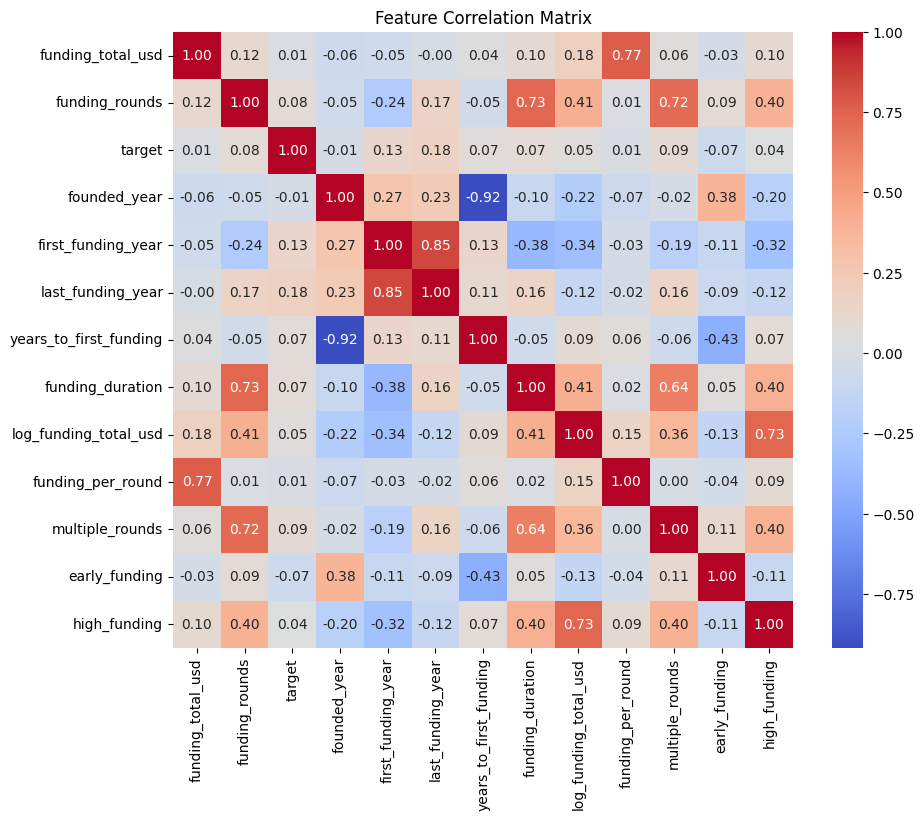

In [82]:
# Correlation heatmap
# Visualize relationships between numerical features


# Correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Feature Correlation Matrix')
plt.show()

In [83]:
# Correlation with target
corr_matrix['target'].sort_values(ascending=False)

target                    1.000000
last_funding_year         0.183009
first_funding_year        0.132620
multiple_rounds           0.086377
funding_rounds            0.078973
funding_duration          0.072640
years_to_first_funding    0.068458
log_funding_total_usd     0.048881
high_funding              0.040911
funding_total_usd         0.011998
funding_per_round         0.005854
founded_year             -0.013406
early_funding            -0.066202
Name: target, dtype: float64

In [84]:
corr_matrix['target'].sort_values(ascending=False)

target                    1.000000
last_funding_year         0.183009
first_funding_year        0.132620
multiple_rounds           0.086377
funding_rounds            0.078973
funding_duration          0.072640
years_to_first_funding    0.068458
log_funding_total_usd     0.048881
high_funding              0.040911
funding_total_usd         0.011998
funding_per_round         0.005854
founded_year             -0.013406
early_funding            -0.066202
Name: target, dtype: float64

In [89]:
# Save feature-engineered data
df_fe.to_csv(
    './raw_data/Big Data SSP Feature Engineering.csv',
    index=False
)

<!-- ##Targets:
##operating
##acquired
##ipo
##closed -->


<!-- Targets:
operating
acquired
ipo
closed -->